In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    """
    多次运行增强，拼接成网格图显示
    Args:
        img: OpenCV格式输入图像（BGR, uint8）
        aug: 可调用增强算子
        num_rows: 网格行数
        num_cols: 网格列数
        scale: 显示缩放比例
    """
    num_total = num_rows * num_cols
    imgs = [aug(img) for _ in range(num_total)]

    # 统一尺寸后拼接大图
    h, w = img.shape[:2]
    big_img = np.zeros((num_rows * h, num_cols * w, 3), dtype=np.uint8)
    for idx in range(num_total):
        r, c = idx // num_cols, idx % num_cols
        resized = cv2.resize(imgs[idx], (w, h), interpolation=cv2.INTER_LINEAR)
        big_img[r*h:(r+1)*h, c*w:(c+1)*w] = resized

    # matplotlib 可视化（转RGB）
    plt.figure(figsize=(num_cols * scale, num_rows * scale))
    plt.imshow(cv2.cvtColor(big_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [2]:
class RandomHorizontalFlip:
    """随机水平翻转"""

    def __init__(self, p: float = 0.5):
        if not 0 <= p <= 1:
            raise ValueError(f"翻转概率p必须在[0,1]区间，当前值: {p}")
        self.p = p

    def __call__(self, img: np.ndarray) -> np.ndarray:
        if np.random.random() < self.p:
            return cv2.flip(img, flipCode=1)  # flipCode=1 水平翻转
        return img.copy()

class RandomVerticalFlip:
    """随机垂直翻转"""

    def __init__(self, p: float = 0.5):
        if not 0 <= p <= 1:
            raise ValueError(f"翻转概率p必须在[0,1]区间，当前值: {p}")
        self.p = p

    def __call__(self, img: np.ndarray) -> np.ndarray:
        if np.random.random() < self.p:
            return cv2.flip(img, flipCode=0)  # flipCode=0 垂直翻转
        return img.copy()

class RandomResizedCrop:
    """随机裁剪 + 缩放"""

    def __init__(
        self,
        size,
        scale: tuple = (0.08, 1.0),
        ratio: tuple = (3.0/4, 4.0/3),
        interpolation: int = cv2.INTER_LINEAR
    ):
        # 参数校验与标准化
        if isinstance(size, int):
            self.size = (size, size)  # (height, width)
        elif isinstance(size, (tuple, list)) and len(size) == 2:
            self.size = tuple(size)
        else:
            raise ValueError("size必须为int或(height, width)元组")

        if len(scale) != 2 or scale[0] > scale[1] or scale[0] <= 0:
            raise ValueError(f"scale必须为正的(min, max)区间，当前值: {scale}")
        self.scale = scale

        if len(ratio) != 2 or ratio[0] > ratio[1] or ratio[0] <= 0:
            raise ValueError(f"ratio必须为正的(min, max)区间，当前值: {ratio}")
        self.ratio = ratio

        self.interpolation = interpolation

    def __call__(self, img: np.ndarray) -> np.ndarray:
        h, w = img.shape[:2]
        origin_area = h * w

        # 最多尝试10次随机采样，匹配失败则回退
        for _ in range(10):
            # 采样目标面积与宽高比
            target_area = origin_area * np.random.uniform(*self.scale)
            aspect_ratio = np.random.uniform(*self.ratio)

            # 计算裁剪宽高
            crop_w = int(round(np.sqrt(target_area * aspect_ratio)))
            crop_h = int(round(np.sqrt(target_area / aspect_ratio)))

            # 合法裁剪区域：随机选左上角
            if 0 < crop_w <= w and 0 < crop_h <= h:
                top = np.random.randint(0, h - crop_h + 1)
                left = np.random.randint(0, w - crop_w + 1)
                crop_img = img[top:top+crop_h, left:left+crop_w]
                # cv2.resize dsize格式为(width, height)，与size顺序相反
                return cv2.resize(crop_img, self.size[::-1], interpolation=self.interpolation)

        # 回退逻辑：中心裁剪最大正方形
        min_side = min(h, w)
        top, left = (h - min_side) // 2, (w - min_side) // 2
        crop_img = img[top:top+min_side, left:left+min_side]
        return cv2.resize(crop_img, self.size[::-1], interpolation=self.interpolation)

class ColorJitter:
    """颜色增强"""

    def __init__(
        self,
        brightness: float = 0,
        contrast: float = 0,
        saturation: float = 0,
        hue: float = 0
    ):
        # 参数合法性校验
        for name, val in [("brightness", brightness), ("contrast", contrast), ("saturation", saturation)]:
            if val < 0:
                raise ValueError(f"{name}不能为负数，当前值: {val}")
        if not 0 <= hue <= 0.5:
            raise ValueError(f"hue必须在[0, 0.5]区间，当前值: {hue}")

        self.brightness = brightness
        self.contrast = contrast
        self.saturation = saturation
        self.hue = hue

    def _adjust_brightness(self, img: np.ndarray, factor: float) -> np.ndarray:
        """亮度调整：像素值线性缩放"""
        img_f = img.astype(np.float32) * factor
        return np.clip(img_f, 0, 255).astype(np.uint8)

    def _adjust_contrast(self, img: np.ndarray, factor: float) -> np.ndarray:
        """对比度调整：基于灰度均值做线性拉伸"""
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
        gray_mean = gray.mean()
        img_f = img.astype(np.float32)
        img_f = factor * (img_f - gray_mean) + gray_mean
        return np.clip(img_f, 0, 255).astype(np.uint8)

    def _adjust_saturation(self, img: np.ndarray, factor: float) -> np.ndarray:
        """饱和度调整：HSV空间S通道缩放"""
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
        hsv[..., 1] = np.clip(hsv[..., 1] * factor, 0, 255)
        return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    def _adjust_hue(self, img: np.ndarray, hue_offset: float) -> np.ndarray:
        """色调调整：HSV空间H通道偏移，OpenCV H范围为0-179（对应0-360°）"""
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
        # 偏移量映射：hue系数 * 180°
        hsv[..., 0] = (hsv[..., 0] + hue_offset * 180) % 180
        hsv[..., 0][hsv[..., 0] < 0] += 180  # 负数取模修正
        return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

    def __call__(self, img: np.ndarray) -> np.ndarray:
        out = img.copy()

        # 1. 亮度调整
        if self.brightness > 0:
            factor = np.random.uniform(max(0, 1 - self.brightness), 1 + self.brightness)
            out = self._adjust_brightness(out, factor)

        # 2. 对比度调整
        if self.contrast > 0:
            factor = np.random.uniform(max(0, 1 - self.contrast), 1 + self.contrast)
            out = self._adjust_contrast(out, factor)

        # 3. 饱和度调整
        if self.saturation > 0:
            factor = np.random.uniform(max(0, 1 - self.saturation), 1 + self.saturation)
            out = self._adjust_saturation(out, factor)

        # 4. 色调调整
        if self.hue > 0:
            offset = np.random.uniform(-self.hue, self.hue)
            out = self._adjust_hue(out, offset)

        return out

class Compose:
    """按顺序串联多个增强"""
    
    def __init__(self, transforms: list):
        self.transforms = transforms

    def __call__(self, img: np.ndarray) -> np.ndarray:
        for aug in self.transforms:
            img = aug(img)
        return img

=== 1. 随机水平翻转 ===


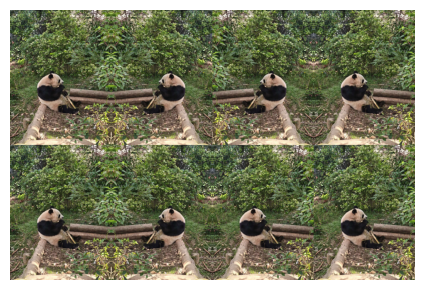

=== 2. 随机垂直翻转 ===


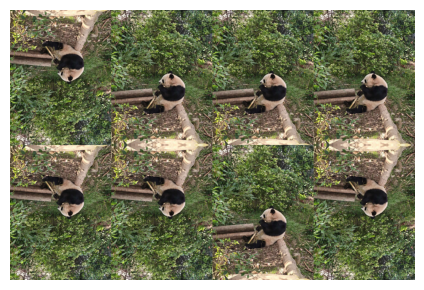

=== 3. RandomResizedCrop 随机裁剪缩放 ===


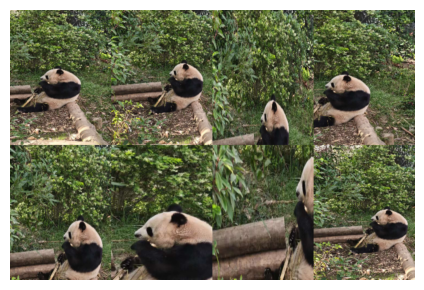

=== 4. 仅随机调整亮度 ===


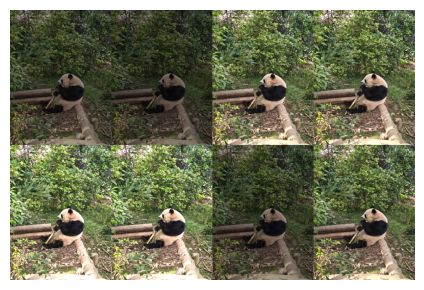

=== 5. 仅随机调整色调 ===


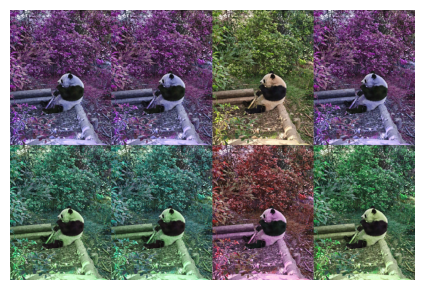

=== 6. 同时抖动亮度/对比度/饱和度/色调 ===


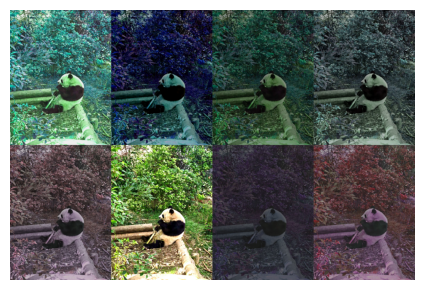

=== 7. 组合多种增强：水平翻转 + 颜色抖动 + 随机裁剪 ===


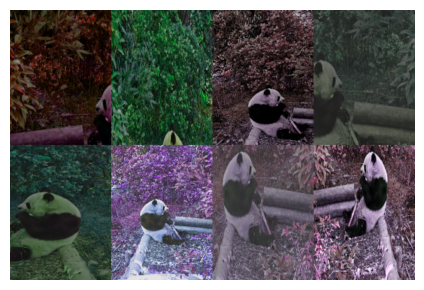

In [3]:
# 读取图像
img_path = r"C:\Users\17934\Desktop\MachineLearning\Program\Computer_Vision\FigureDataSet\panda.jpg"
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError("图像文件不存在，请检查路径")

print("=== 1. 随机水平翻转 ===")
apply(img, RandomHorizontalFlip(p=0.5))

print("=== 2. 随机垂直翻转 ===")
apply(img, RandomVerticalFlip(p=0.5))

print("=== 3. RandomResizedCrop 随机裁剪缩放 ===")
shape_aug = RandomResizedCrop(size=(200, 200), scale=(0.1, 1), ratio=(0.5, 2))
apply(img, shape_aug)

print("=== 4. 仅随机调整亮度 ===")
brightness_aug = ColorJitter(brightness=0.5, contrast=0, saturation=0, hue=0)
apply(img, brightness_aug)

print("=== 5. 仅随机调整色调 ===")
hue_aug = ColorJitter(brightness=0, contrast=0, saturation=0, hue=0.5)
apply(img, hue_aug)

print("=== 6. 同时抖动亮度/对比度/饱和度/色调 ===")
color_aug = ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5)
apply(img, color_aug)

print("=== 7. 组合多种增强：水平翻转 + 颜色抖动 + 随机裁剪 ===")
all_augs = Compose([
    RandomHorizontalFlip(),
    color_aug,
    shape_aug
])
apply(img, all_augs)

In [3]:
"加载训练和测试的数据集"

import torch
from torch.utils.data import DataLoader
from PIL import Image
import torchvision


def pil_to_cv2(pil_img: Image.Image) -> np.ndarray:
    """PIL RGB图像 → OpenCV BGR uint8图像"""

    img_np = np.array(pil_img)  # shape: [H, W, C] 通道顺序 RGB
    return cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

def cv2_to_tensor(cv2_img: np.ndarray) -> torch.Tensor:
    """
    OpenCV BGR图像 → PyTorch训练标准张量
    输出格式：[C, H, W] float32 像素范围 [0, 1]
    """

    # BGR转回RGB，匹配深度学习常规通道顺序
    img_rgb = cv2.cvtColor(cv2_img, cv2.COLOR_BGR2RGB)
    # 维度换位 + 类型转换 + 归一化
    tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
    return tensor

def load_cifar10_cv2(
    is_train: bool,
    cv2_augs: Compose,
    batch_size: int,
    root: str,
) -> DataLoader:
    """
    加载数据集：torchvision 自动下载 + OpenCV 增强 + 输出训练兼容张量
    Args:
        is_train: True加载训练集（打乱+增强），False加载测试集（不打乱无增强）
        cv2_augs: OpenCV增强组合（Compose对象），测试集传 Compose([]) 即可
        batch_size: 批次大小
        root: 数据集本地存放路径
    Returns:
        DataLoader，每次迭代返回 (images, labels)
        images shape: [batch, 3, H, W] torch.float32 范围[0,1]
        labels shape: [batch] torch.long
    """
    # 单张图预处理流水线：PIL → OpenCV → 增强 → 训练张量
    def transform_fn(pil_img):
        cv_img = pil_to_cv2(pil_img)
        aug_img = cv2_augs(cv_img)
        return cv2_to_tensor(aug_img)

    # 1. torchvision 自动下载/加载数据集
    dataset = torchvision.datasets.CIFAR10(
        root=root,
        train=is_train,
        transform=transform_fn,
        download=True
    )

    # 2. 构建数据迭代器
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=is_train,       # 训练集打乱，测试集固定顺序
        num_workers=0,          # Windows固定0，Linux可改为CPU核心数提速
        drop_last=False
    )
    return loader


In [4]:
# 训练集：随机翻转 + 颜色抖动 + 随机裁剪缩放
train_augs = Compose([
    RandomHorizontalFlip(p=0.5),
    ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    RandomResizedCrop(size=32, scale=(0.8, 1.0), ratio=(3/4, 4/3))
])
# 测试集：无任何随机增强，仅做格式转换
test_augs = Compose([])

batch_size = 64
root_path = r'C:\Users\17934\Desktop\MachineLearning\Program\Computer_Vision\FigureDataSet'
train_loader = load_cifar10_cv2(is_train=True, cv2_augs=train_augs, batch_size=batch_size, root=root_path)
test_loader = load_cifar10_cv2(is_train=False, cv2_augs=test_augs, batch_size=batch_size, root=root_path)


100%|██████████| 170M/170M [4:11:12<00:00, 11.3kB/s]   


In [5]:
"模型训练"
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
from collections import defaultdict
from torchvision.models import resnet18

def get_device():
    if torch.cuda.is_available():
        return [torch.device(f'cuda:{i}') for i in range(torch.cuda.device_count())]
    return [torch.device('cpu')]

class Timer:
    def __init__(self):
        self.total_time = 0.0
        self.start_time = None
    def start(self):
        self.start_time = time.time()
    def stop(self):
        if self.start_time is None: return
        self.total_time += time.time() - self.start_time
        self.start_time = None
    def sum(self):
        return self.total_time


class Accumulator:
    """多变量累加器，用于统计全局平均指标"""

    def __init__(self, n):
        self.data = [0.0] * n
    def add(self, *args):
        for i, v in enumerate(args):
            self.data[i] += float(v)
    def __getitem__(self, idx):
        return self.data[idx]

def calculate_batch_accuracy(pred, labels):
    """计算一个batch的预测正确样本数"""

    pred_labels = torch.argmax(pred, dim=1)
    return (pred_labels == labels).sum().item()

def evaluate_accuracy(net, test_loader, device):
    """计算验证集整体准确率，自动兼容DataParallel包装的模型"""
 
    net.eval()
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            pred = net(X)
            total_correct += calculate_batch_accuracy(pred, y)
            total_samples += y.numel()
    return total_correct / total_samples if total_samples > 0 else 0.0

def build_resnet18_cifar10(num_classes=10):
    """
    构建适配32x32输入的ResNet-18
    修改首层卷积 + 移除最大池化，避免小尺寸图片信息丢失
    """

    net = resnet18(weights=None, num_classes=num_classes)
    net.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    net.maxpool = nn.Identity()  # 移除原7x7卷积后的最大池化
    return net

def init_weights(m):
    """Xavier均匀初始化"""

    if type(m) in [nn.Linear, nn.Conv2d]:
        nn.init.xavier_uniform_(m.weight)

In [8]:
def train_batch_ch13(net, X, y, loss_fn, optimizer, device):
    """
    单批次训练核心
    返回: 当前batch损失总和、正确样本数
    """

    if isinstance(X, list):
        X = [x.to(device) for x in X]
    else:
        X = X.to(device)
    y = y.to(device)

    net.train()
    optimizer.zero_grad()
    pred = net(X)
    loss = loss_fn(pred, y)  # reduction='none'，输出逐样本损失
    loss.sum().backward()
    optimizer.step()

    return loss.sum().item(), calculate_batch_accuracy(pred, y)


def train_ch13(net, train_loader, test_loader, loss_fn, optimizer, num_epochs, devices):
    timer = Timer()
    main_device = devices[0]

    # 多GPU自动包装：仅多卡环境启用DataParallel
    if len(devices) > 1 and main_device.type == 'cuda':
        net = nn.DataParallel(net, device_ids=[d.index for d in devices])
    net = net.to(main_device)

    history = defaultdict(list)  # 记录训练曲线
    best_test_acc = 0.0          # 记录最优测试准确率

    for epoch in range(num_epochs):
        metric = Accumulator(3)  # 总损失、总正确数、总样本数
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")

        # 训练一个Epoch
        for X, y in pbar:
            timer.start()
            loss_sum, acc_sum = train_batch_ch13(net, X, y, loss_fn, optimizer, main_device)
            timer.stop()

            batch_size = y.numel()
            metric.add(loss_sum, acc_sum, batch_size)

            # 进度条实时显示指标
            avg_loss = metric[0] / metric[2]
            avg_acc = metric[1] / metric[2]
            pbar.set_postfix({"loss": f"{avg_loss:.4f}", "acc": f"{avg_acc:.4f}"})

        # Epoch结束：验证集评估
        test_acc = evaluate_accuracy(net, test_loader, main_device)
        train_loss = metric[0] / metric[2]
        train_acc = metric[1] / metric[2]

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        # 自动保存最优模型
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(net.state_dict(), "best_resnet18_cifar10.pth")

        # Epoch总结日志
        print(f"\n>>> Epoch {epoch+1} 完成：")
        print(f"训练损失: {train_loss:.4f} | 训练准确率: {train_acc:.4f}")
        print(f"测试准确率: {test_acc:.4f} | 历史最优: {best_test_acc:.4f}\n")

    # 训练速度统计
    total_samples = metric[2] * num_epochs
    speed = total_samples / timer.sum()
    print(f"训练全部完成！平均速度: {speed:.1f} samples/sec")
    print(f"运行设备: {[str(d) for d in devices]}")

    # 绘制训练曲线（替代原d2l.Animator）
    epochs = range(1, num_epochs+1)
    plt.figure(figsize=(10, 4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    plt.plot(epochs, history['test_acc'], 'r--', label='Test Acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.show()

    return history, best_test_acc

def train_with_data_aug(train_augs, test_augs, net, lr=0.001, batch_size=64, num_epochs=10, root=str):
    # 加载OpenCV增强版数据集
    train_loader = load_cifar10_cv2(True, train_augs, batch_size, root)
    test_loader = load_cifar10_cv2(False, test_augs, batch_size, root)

    # 损失+优化器，和教材完全一致
    loss_fn = nn.CrossEntropyLoss(reduction='none')
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    devices = get_device()

    return train_ch13(net, train_loader, test_loader, loss_fn, optimizer, num_epochs, devices)

Epoch 1/10: 100%|██████████| 782/782 [00:48<00:00, 16.20batch/s, loss=1.3502, acc=0.5183]



>>> Epoch 1 完成：
训练损失: 1.3502 | 训练准确率: 0.5183
测试准确率: 0.6357 | 历史最优: 0.6357



Epoch 2/10: 100%|██████████| 782/782 [00:47<00:00, 16.46batch/s, loss=0.8523, acc=0.7030]



>>> Epoch 2 完成：
训练损失: 0.8523 | 训练准确率: 0.7030
测试准确率: 0.6941 | 历史最优: 0.6941



Epoch 3/10: 100%|██████████| 782/782 [00:48<00:00, 16.25batch/s, loss=0.6882, acc=0.7614]


...


>>> Epoch 8 完成：
训练损失: 0.3926 | 训练准确率: 0.8643
测试准确率: 0.8350 | 历史最优: 0.8430



Epoch 9/10: 100%|██████████| 782/782 [00:49<00:00, 15.87batch/s, loss=0.3635, acc=0.8747]



>>> Epoch 9 完成：
训练损失: 0.3635 | 训练准确率: 0.8747
测试准确率: 0.8546 | 历史最优: 0.8546



Epoch 10/10: 100%|██████████| 782/782 [00:48<00:00, 16.13batch/s, loss=0.3298, acc=0.8851]



>>> Epoch 10 完成：
训练损失: 0.3298 | 训练准确率: 0.8851
测试准确率: 0.8476 | 历史最优: 0.8546

训练全部完成！平均速度: 1328.4 samples/sec
运行设备: ['cuda:0']


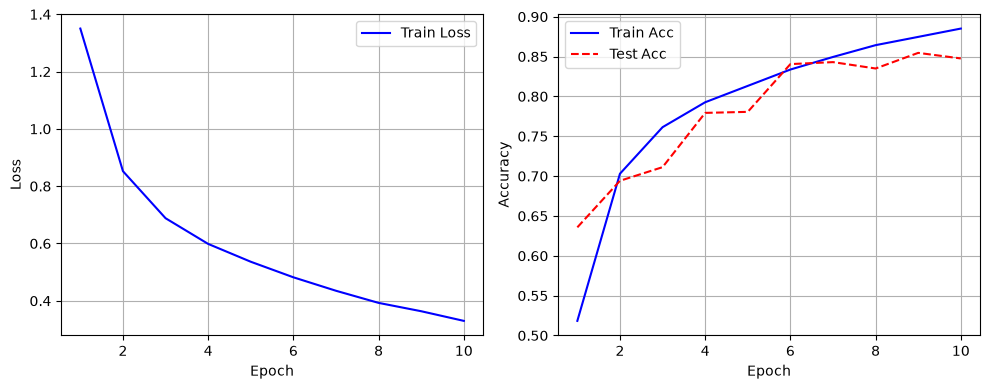

In [9]:
net = build_resnet18_cifar10(num_classes=10)
net.apply(init_weights)

history, best_acc = train_with_data_aug(
        train_augs=train_augs,
        test_augs=test_augs,
        net=net,
        lr=0.001,
        batch_size=64,
        num_epochs=10,
        root=root_path
    )

成功加载历史权重


Epoch 1/10: 100%|██████████| 782/782 [00:50<00:00, 15.43batch/s, loss=0.2432, acc=0.9164]



>>> Epoch 1 完成：
训练损失: 0.2432 | 训练准确率: 0.9164
测试准确率: 0.8809 | 历史最优: 0.8809



Epoch 2/10: 100%|██████████| 782/782 [00:50<00:00, 15.45batch/s, loss=0.2222, acc=0.9229]



>>> Epoch 2 完成：
训练损失: 0.2222 | 训练准确率: 0.9229
测试准确率: 0.8575 | 历史最优: 0.8809



...


>>> Epoch 8 完成：
训练损失: 0.1439 | 训练准确率: 0.9497
测试准确率: 0.8931 | 历史最优: 0.8931



Epoch 9/10: 100%|██████████| 782/782 [00:49<00:00, 15.86batch/s, loss=0.1384, acc=0.9516]



>>> Epoch 9 完成：
训练损失: 0.1384 | 训练准确率: 0.9516
测试准确率: 0.8932 | 历史最优: 0.8932



Epoch 10/10: 100%|██████████| 782/782 [00:49<00:00, 15.94batch/s, loss=0.1263, acc=0.9568]



>>> Epoch 10 完成：
训练损失: 0.1263 | 训练准确率: 0.9568
测试准确率: 0.8928 | 历史最优: 0.8932

训练全部完成！平均速度: 1330.4 samples/sec
运行设备: ['cuda:0']


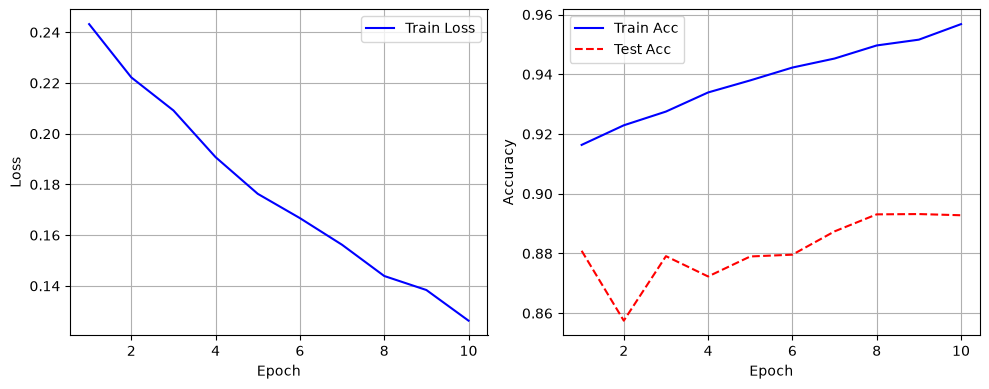

In [12]:
"继续叠加训练"

import os

weight_path = "best_resnet18_cifar10.pth"

if os.path.exists(weight_path):
    # 兼容多GPU训练保存的权重（自动去除module.前缀）
    state_dict = torch.load(weight_path, map_location="cpu")
    new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    net.load_state_dict(new_state_dict)
    print(f"成功加载历史权重")
else:
    net.apply(init_weights)
    print("未找到历史权重")

history, best_acc = train_with_data_aug(
    train_augs=train_augs,
    test_augs=test_augs,
    net=net,
    lr=0.001,
    batch_size=64,
    num_epochs=10,
    root=root_path
)